In [1]:
import rasterio 

In [4]:
in_img = r'/Users/tsukki/rasterio_course/data/geotiff/nepal_lc_2020.tif'
ds = rasterio.open(in_img)
ds

data = ds.read()

In [4]:
data

array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]],
      shape=(1, 1485, 2932), dtype=uint8)

In [5]:
ds.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 255.0,
 'width': 2932,
 'height': 1485,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(0.0027777777777780012, 0.0, 80.05847091000004,
        0.0, -0.0027777777777780012, 30.472819010000357)}

In [5]:
ds.count
 

1

In [7]:
ds.shape

(1485, 2932)

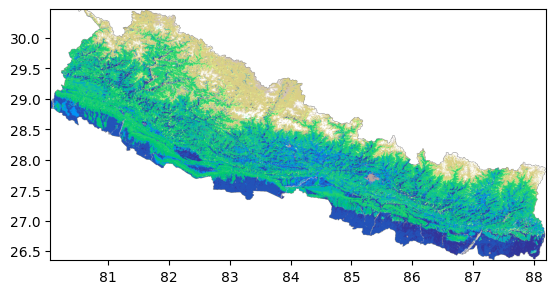

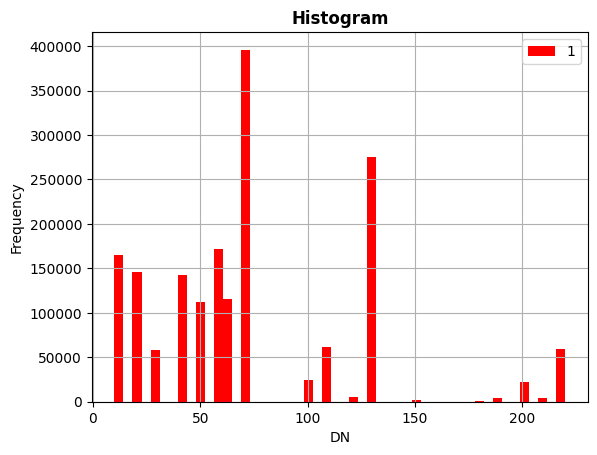

In [6]:
from rasterio.plot import show , show_hist
show(ds , cmap = 'terrain')
show_hist(ds , bins=50)

In [14]:
import os
import rasterio

# Create the output directory if it doesn't exist
os.makedirs(r"/Users/tsukki/rasterio_course/outputs", exist_ok=True)

with rasterio.open(r"/Users/tsukki/rasterio_course/outputs/nepal_lc_2020_out.tif", 'w', 
                    driver=ds.driver,
                    height=ds.height,
                    width=ds.width,
                    count=ds.count,
                    crs=ds.crs,
                    transform=ds.transform,
                    dtype=data.dtype,
                    ) as dst:   
    dst.write(data)

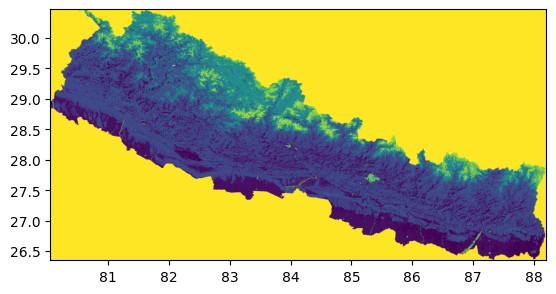

<Axes: >

In [16]:
ds_out = rasterio.open(r"/Users/tsukki/rasterio_course/outputs/nepal_lc_2020_out.tif")
show(ds_out)  

In [21]:
import numpy as np
ds = rasterio.open(in_img)
data = ds.read()

lista = data.copy()
lista[np.where((lista>=10) & (lista<=40))] = 1 #Agriculture
lista[np.where((lista>=50) & (lista<=100))] = 2 #Forest
lista[np.where((lista>=110) & (lista<=180))] = 3 #Grassland
lista[np.where(lista>=190)] = 4 #Urban
lista[np.where(lista>=200)] = 5 #Bare Land
lista[np.where((lista >= 210)&(lista <= 200))] = 6 #Water

with rasterio.open(r"/Users/tsukki/rasterio_course/outputs/reclassify.tif", 'w',
                    driver=ds.driver,
                    height=ds.height,
                    width=ds.width,
                    count=ds.count,
                    crs=ds.crs,
                    transform=ds.transform,
                    dtype= data.dtype,
                    ) as dst:   
    dst.write(lista)

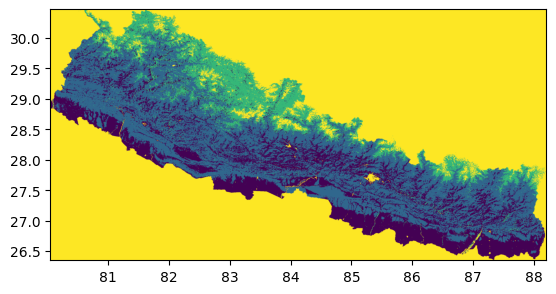

<Axes: >

In [23]:
ds_out = rasterio.open(r"/Users/tsukki/rasterio_course/outputs/reclassify.tif")
show(ds_out)  

In [24]:
from shapely.geometry import Polygon , LineString , Point

p1 = Point(85.3240, 27.7172) #Kathmandu
p2 = Point(80 , 25) #Random Point   
l1 = LineString([(85.3240, 27.7172), (80 , 25)])
poly1 = Polygon([(85.3240, 27.7172), (80 , 25), (80 , 30)]) 



In [28]:
import geopandas as gpd
geoseries_shape = gpd.GeoSeries( [p1, p2, l1, poly1])
df_shape = gpd.GeoDataFrame(geoseries_shape)
df_shape.columns = ['geometry']
df_shape = gpd.GeoDataFrame(geometry=geoseries_shape)  # ✅ set geometry at creation
df_shape = df_shape.set_crs("EPSG:4326") # Set CRS to WGS84 (EPSG:4326)



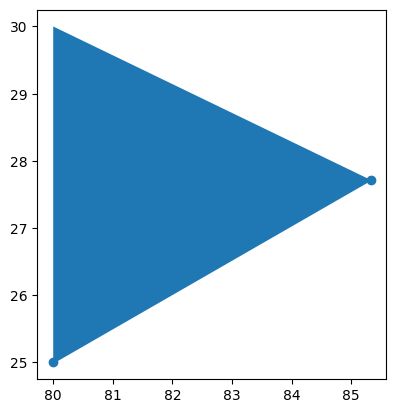

In [29]:
import matplotlib.pyplot as plt
df_shape.plot()
plt.show()

In [32]:
import fiona

with fiona.open(r"/Users/tsukki/rasterio_course/data/shp/pokhara.shp", 'r') as shapefile:
    for feature in shapefile:
     shapes =  [feature['geometry']]

In [33]:
shapes

[fiona.Geometry(coordinates=[[(84.01857429100005, 28.327647271000046), ...]], type='Polygon')]